In [15]:
import pandas as pd

df = pd.read_csv('diamonds_full.csv',encoding='utf-8')

In [ ]:
#Preprocessing for Clustering
import pickle
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Drop price-related and derived columns
selected_features = ['carat', 'x', 'y', 'z', 'depth', 'table', 'volume', 'cut', 'color', 'clarity']
df_cluster = df[selected_features].copy()

# Encode categorical features
encoder = OrdinalEncoder()
df_cluster[['cut', 'color', 'clarity']] = encoder.fit_transform(df_cluster[['cut', 'color', 'clarity']])


with open('encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)


scaler_clust = StandardScaler()
X_scaled = scaler_clust.fit_transform(df_cluster)

with open('scaler_clust.pkl', 'wb') as f:
    pickle.dump(scaler_clust, f)


Silhouette Scores for k=2 to 10: [0.3353563430751761, 0.19345201609805387, 0.1614678087107696, 0.16756895276464331, 0.15286821327664785, 0.17206334212111682, 0.1595735196144332, 0.16086441697097137, 0.1655604601054618]


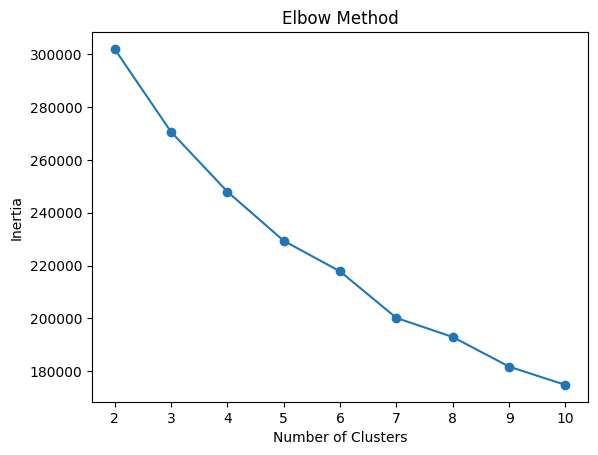

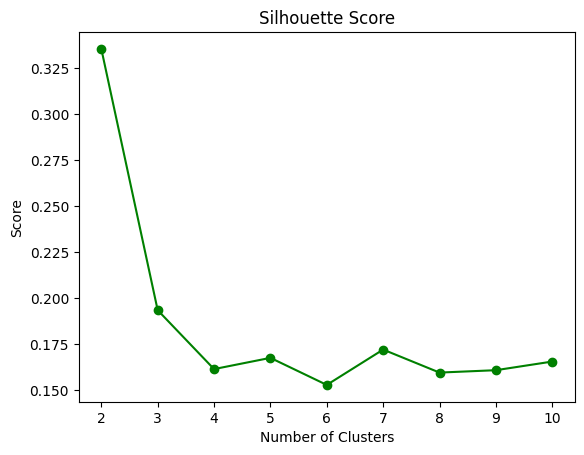

In [17]:
#Elbow Method & Silhouette Score (KMeans)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Elbow method and Silhouette Score
inertia = []
sil_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Print Silhouette Scores
print("Silhouette Scores for k=2 to 10:", sil_scores)

# Plot Elbow
plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Plot Silhouette Score
plt.plot(range(2, 11), sil_scores, marker='o', color='green')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.show()



In [18]:
#clustering algorithms

from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np

# DBSCAN clustering
dbscan = DBSCAN(eps=1.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
dbscan_sil_score = silhouette_score(X_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])

# Agglomerative clustering
hierarchical = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)
hierarchical_sil_score = silhouette_score(X_scaled, hierarchical_labels)

# Output
print("DBSCAN labels:", np.unique(dbscan_labels))
print("DBSCAN Silhouette Score:", dbscan_sil_score)

print("Agglomerative labels:", np.unique(hierarchical_labels))
print("Agglomerative Silhouette Score:", hierarchical_sil_score)



DBSCAN labels: [-1  0  1  2  3  4  5]
DBSCAN Silhouette Score: 0.1423629918023416
Agglomerative labels: [0 1 2 3]
Agglomerative Silhouette Score: 0.14994201097283855


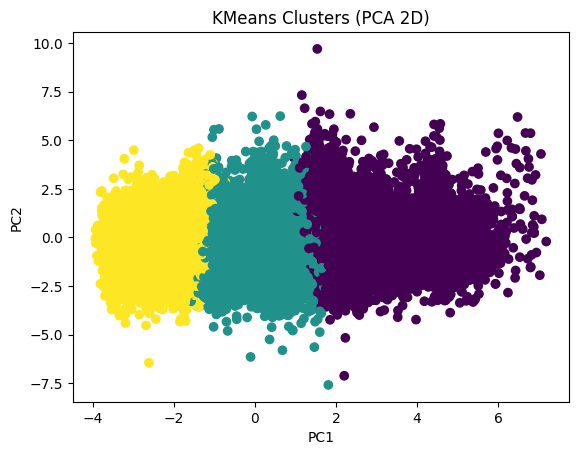

In [ ]:
#PCA(Principal component analysis) for Visualization

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualize KMeans clusters
kmeans_final = KMeans(n_clusters=3, random_state=42).fit(X_scaled)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_final.labels_, cmap='viridis')
plt.title('KMeans Clusters (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


In [ ]:
#Cluster Profiling & Naming

df['cluster'] = kmeans_final.labels_
cluster_summary = df.groupby('cluster')[['price_inr', 'carat']].mean()
cluster_cut_dist = df.groupby('cluster')['cut'].value_counts(normalize=True)


def name_cluster(row):
    if row['carat'] > 1.5 and row['price_inr'] > 500000:
        return "Premium Heavy Diamonds"
    elif row['carat'] < 0.5 and row['price_inr'] < 100000:
        return "Affordable Small Diamonds"
    else:
        return "Mid-range Balanced Diamonds"

cluster_summary['name'] = cluster_summary.apply(name_cluster, axis=1)
print(cluster_summary[['price_inr', 'carat', 'name']])


             price_inr     carat                         name
cluster                                                      
0        529424.943156  1.145984  Mid-range Balanced Diamonds
1        210157.032962  0.666609  Mid-range Balanced Diamonds
2         77075.460866  0.358396    Affordable Small Diamonds


In [21]:
#Saving Best Clustering Model

import pickle

with open('best_clustering_model.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)
